# **Experiments #3 — POA with Randomize Initialization**

### Objectives
- Prove which scheduling order is best (Teachers→Rooms→Slots / Rooms→Teachers→Slots / Slots→Rooms→Teachers)
- Prove teacher-lab-expertise scheduling is more effective
- Measure the % of teachers not teaching in their lab domain
- Prove computational environment affects solution quality

### Algorithm source
Faithful Python translation of the original MATLAB POA:
`Puma.m` · `Exploration.m` · `Exploitation.m`

---

# **Data Setup**

## *Import Used Library*

In [3]:
# ─────────────────────────────────────────────────────────────
# Cell 1 ▸ Import Used Libraries
# ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import random
import time
import math
import warnings
from collections import defaultdict
from itertools import combinations
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
random.seed(GLOBAL_SEED)

print("Libraries loaded.")
print(f"NumPy  : {np.__version__}")
print(f"Pandas : {pd.__version__}")


Libraries loaded.
NumPy  : 1.26.4
Pandas : 2.1.4


## *Dataset Understanding*

Courses, teachers, laboratories, rooms, timeslots

In [4]:
# ─────────────────────────────────────────────────────────────
# Cell 2 ▸ Dataset Understanding
# ─────────────────────────────────────────────────────────────
df_courses_raw   = pd.read_csv("/home/emery/Documents/Scheduling_Puma_Optimizer/app/assets/data/mk_dsi.csv")
df_lab_expertise = pd.read_csv("/home/emery/Documents/Scheduling_Puma_Optimizer/app/assets/data/teacher_lab_expertise.csv")
df_rooms_all     = pd.read_csv("/home/emery/Documents/Scheduling_Puma_Optimizer/app/assets/data/rooms.csv")
df_prac_rooms    = pd.read_csv("/home/emery/Documents/Scheduling_Puma_Optimizer/app/assets/data/practicum_rooms.csv")
df_days_raw      = pd.read_csv("/home/emery/Documents/Scheduling_Puma_Optimizer/app/assets/data/days.csv")

# Global time constants (used throughout)
DAYS          = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
SLOTS_PER_DAY = 13      # 13 slots × 50 min = 650 min/day
SLOT_DURATION = 50      # minutes per slot
START_HOUR    = 7       # first slot 07:00

slot_labels = [
    f"{(START_HOUR*60 + i*SLOT_DURATION)//60:02d}:{(START_HOUR*60 + i*SLOT_DURATION)%60:02d}"
    for i in range(SLOTS_PER_DAY)
]

print("=" * 60)
print("COURSES DATASET  (mk_dsi.csv)")
print("=" * 60)
print(df_courses_raw.head(5).to_string(index=False))
print(f"\nShape           : {df_courses_raw.shape}")
print(f"Unique course_id: {df_courses_raw['course_id'].nunique()}")
print(f"Unique prodi    : {df_courses_raw['prodi'].nunique()}")
print(f"Unique teachers : {df_courses_raw['teacher_id'].nunique()}")
print("\nSemester  :", df_courses_raw["course_genap_ganjil"].value_counts().to_dict())
print("Type      :", df_courses_raw["course_type"].value_counts().to_dict())
print("Practicum :", df_courses_raw["course_has_practicum"].value_counts().to_dict())
print("SKS range :", df_courses_raw["sks"].min(), "–", df_courses_raw["sks"].max())

print("\n" + "=" * 60)
print("TEACHER LAB EXPERTISE  (teacher_lab_expertise.csv)")
print("=" * 60)
print(df_lab_expertise.head(8).to_string(index=False))
print("\nLab dist.:", df_lab_expertise["lab"].value_counts().to_dict())

print("\n" + "=" * 60)
print("ROOMS")
print("=" * 60)
print(f"Theory rooms: {len(df_rooms_all)}  |  Practicum rooms: {len(df_prac_rooms)}")
print(f"Slot times  : {slot_labels}")


COURSES DATASET  (mk_dsi.csv)
course_id                                 course_name                          prodi  sks course_genap_ganjil course_type course_has_practicum  teacher_priority teacher_position teacher_id
 CSD60704                           Desain Basis Data            Teknologi Informasi    2               Genap       Wajib                Tidak                 1         Pengampu          1
 CIT62022 Implementasi dan Pengujian Sistem Informasi            Teknologi Informasi    2               Genap       Wajib                Tidak                 1         Pengampu          1
 CIT60048                       Information Retrieval            Teknologi Informasi    2        Ganjil/Genap     Pilihan                Tidak                 1         Pengampu          1
 CSD60714            Jaminan Kualitas Perangkat Lunak Pendidikan Teknologi Informasi    3               Genap       Wajib                Tidak                 1         Pengampu          1
 CSD60714            Jami

## *Splitting Course Ganjil — Genap*

In [5]:
# ─────────────────────────────────────────────────────────────
# Cell 3 ▸ Splitting Courses: Ganjil vs Genap
# ─────────────────────────────────────────────────────────────
GENAP_VALUES = ["Genap", "Ganjil/Genap"]

df_genap  = df_courses_raw[df_courses_raw["course_genap_ganjil"].isin(GENAP_VALUES)].copy()
df_ganjil = df_courses_raw[df_courses_raw["course_genap_ganjil"] == "Ganjil"].copy()
df_working = df_genap.copy()

print(f"Total rows           : {len(df_courses_raw)}")
print(f"Genap rows           : {len(df_genap)}")
print(f"Ganjil-only rows     : {len(df_ganjil)}")

genap_off = df_genap.drop_duplicates(["course_id","prodi"])
print(f"Unique Genap offerings (course×prodi): {len(genap_off)}")
print("\nSample (Genap):")
print(genap_off[["course_id","course_name","prodi","sks"]].head(8).to_string(index=False))


Total rows           : 846
Genap rows           : 602
Ganjil-only rows     : 244
Unique Genap offerings (course×prodi): 96

Sample (Genap):
course_id                                 course_name                          prodi  sks
 CSD60704                           Desain Basis Data            Teknologi Informasi    2
 CIT62022 Implementasi dan Pengujian Sistem Informasi            Teknologi Informasi    2
 CIT60048                       Information Retrieval            Teknologi Informasi    2
 CSD60714            Jaminan Kualitas Perangkat Lunak Pendidikan Teknologi Informasi    3
 CSD60714            Jaminan Kualitas Perangkat Lunak            Teknologi Informasi    3
 COM60024                          Pemrograman Lanjut               Sistem Informasi    5
 COM60024                          Pemrograman Lanjut            Teknologi Informasi    5
 CSD60705                             Pemrograman SQL               Sistem Informasi    3


## *Splitting Selected Courses by Theory and Practicum*

In [6]:
# ─────────────────────────────────────────────────────────────
# Cell 4 ▸ Splitting Courses: Theory vs Practicum
# ─────────────────────────────────────────────────────────────
df_offerings = (
    df_working
    .drop_duplicates(["course_id", "prodi"])
    [["course_id","course_name","prodi","sks","course_type","course_has_practicum"]]
    .reset_index(drop=True)
)

df_theory    = df_offerings[df_offerings["course_has_practicum"] == "Tidak"]
df_practicum = df_offerings[df_offerings["course_has_practicum"] == "Ya"]

print(f"Total offerings : {len(df_offerings)}")
print(f"  Theory-only   : {len(df_theory)}")
print(f"  Has practicum : {len(df_practicum)}")

# Build scheduling units  (1 theory unit per offering; +1 practicum unit if Ya)
scheduling_units = []
for _, r in df_offerings.iterrows():
    scheduling_units.append({
        "unit_id"     : f"{r['course_id']}__{r['prodi']}__TH",
        "course_id"   : r["course_id"],
        "course_name" : r["course_name"],
        "prodi"       : r["prodi"],
        "sks"         : r["sks"],
        "course_type" : r["course_type"],
        "session_type": "Theory",
    })
    if r["course_has_practicum"] == "Ya":
        scheduling_units.append({
            "unit_id"     : f"{r['course_id']}__{r['prodi']}__PR",
            "course_id"   : r["course_id"],
            "course_name" : r["course_name"],
            "prodi"       : r["prodi"],
            "sks"         : r["sks"],
            "course_type" : r["course_type"],
            "session_type": "Practicum",
        })

df_units = pd.DataFrame(scheduling_units)
n_units  = len(df_units)
print(f"\nScheduling units : {n_units}")
print(f"  Theory   : {(df_units['session_type']=='Theory').sum()}")
print(f"  Practicum: {(df_units['session_type']=='Practicum').sum()}")
print("\nSample units:")
print(df_units[["unit_id","sks","course_type","session_type"]].head(10).to_string(index=False))


Total offerings : 96
  Theory-only   : 80
  Has practicum : 16

Scheduling units : 112
  Theory   : 96
  Practicum: 16

Sample units:
                                     unit_id  sks course_type session_type
           CSD60704__Teknologi Informasi__TH    2       Wajib       Theory
           CIT62022__Teknologi Informasi__TH    2       Wajib       Theory
           CIT60048__Teknologi Informasi__TH    2     Pilihan       Theory
CSD60714__Pendidikan Teknologi Informasi__TH    3       Wajib       Theory
           CSD60714__Teknologi Informasi__TH    3     Pilihan       Theory
              COM60024__Sistem Informasi__TH    5       Wajib       Theory
              COM60024__Sistem Informasi__PR    5       Wajib    Practicum
           COM60024__Teknologi Informasi__TH    5       Wajib       Theory
           COM60024__Teknologi Informasi__PR    5       Wajib    Practicum
              CSD60705__Sistem Informasi__TH    3       Wajib       Theory


## *Generated Course Time based on SKS*

In [7]:
# ─────────────────────────────────────────────────────────────
# Cell 5 ▸ Generated Course Time based on SKS
#   SKS <= 3  →  100 min  =  2 slots
#   SKS >= 4  →  150 min  =  3 slots
# ─────────────────────────────────────────────────────────────
def sks_to_slots(sks: int) -> int:
    return 2 if sks <= 3 else 3

df_units["slots_needed"]   = df_units["sks"].apply(sks_to_slots)
df_units["duration_mins"]  = df_units["slots_needed"] * SLOT_DURATION
df_units["max_start_slot"] = SLOTS_PER_DAY - df_units["slots_needed"]

print("SKS → slot mapping:")
for sks_val in sorted(df_units["sks"].unique()):
    s = sks_to_slots(sks_val)
    cnt = (df_units["sks"] == sks_val).sum()
    print(f"  SKS {sks_val:2d} → {s} slots ({s*SLOT_DURATION} min)  max_start={SLOTS_PER_DAY-s}"
          f"  [{cnt} units]")

print("\nSample with time info:")
print(df_units[["unit_id","sks","slots_needed","duration_mins","max_start_slot"]].head(8).to_string(index=False))


SKS → slot mapping:
  SKS  2 → 2 slots (100 min)  max_start=11  [26 units]
  SKS  3 → 2 slots (100 min)  max_start=11  [75 units]
  SKS  4 → 3 slots (150 min)  max_start=10  [7 units]
  SKS  5 → 3 slots (150 min)  max_start=10  [4 units]

Sample with time info:
                                     unit_id  sks  slots_needed  duration_mins  max_start_slot
           CSD60704__Teknologi Informasi__TH    2             2            100              11
           CIT62022__Teknologi Informasi__TH    2             2            100              11
           CIT60048__Teknologi Informasi__TH    2             2            100              11
CSD60714__Pendidikan Teknologi Informasi__TH    3             2            100              11
           CSD60714__Teknologi Informasi__TH    3             2            100              11
              COM60024__Sistem Informasi__TH    5             3            150              10
              COM60024__Sistem Informasi__PR    5             3          

## *Splitting Teachers based on Courses Coordinator or Not*

In [8]:
# ─────────────────────────────────────────────────────────────
# Cell 6 ▸ Splitting Teachers: Coordinator vs Non-Coordinator
# ─────────────────────────────────────────────────────────────
MAX_WEEKLY_MINUTES = 2400   # 40 hrs/week

df_working["teacher_position"] = df_working["teacher_position"].str.strip()
df_working["teacher_id"]       = df_working["teacher_id"].astype(str)
df_lab_expertise["lecturer_id"] = df_lab_expertise["lecturer_id"].astype(str)

# Lab expertise lookup
teacher_lab = {
    str(r["lecturer_id"]): r["lab"]
    for _, r in df_lab_expertise.iterrows()
}

# Teacher priority lookup: (teacher_id, unit_id) → int
teacher_priority = {}
for _, row in df_working.iterrows():
    cid  = row["course_id"]
    prod = row["prodi"]
    t_id = str(row["teacher_id"])
    for sfx in ["TH", "PR"]:
        uid = f"{cid}__{prod}__{sfx}"
        try:
            teacher_priority[(t_id, uid)] = int(row["teacher_priority"])
        except (ValueError, TypeError):
            teacher_priority[(t_id, uid)] = 2

# Eligible teachers per unit
eligible_teachers = {}
for _, unit in df_units.iterrows():
    uid  = unit["unit_id"]
    mask = ((df_working["course_id"] == unit["course_id"]) &
            (df_working["prodi"]     == unit["prodi"]))
    teachers = df_working.loc[mask, "teacher_id"].dropna().unique().tolist()
    eligible_teachers[uid] = teachers if teachers else ["TBA"]

# Coordinator flag
coordinator_teachers = set(
    df_working[df_working["teacher_position"].str.contains("Koordinator", na=False)]["teacher_id"]
)
non_coord_teachers = (
    set(df_working["teacher_id"]) - coordinator_teachers
)

print(f"Unique teachers in working set  : {df_working['teacher_id'].nunique()}")
print(f"  Coordinators                  : {len(coordinator_teachers)}")
print(f"  Non-coordinators              : {len(non_coord_teachers)}")
print(f"  With lab expertise record     : {len(teacher_lab)}")

print("\nSample eligible teacher counts per unit:")
for uid, tlist in list(eligible_teachers.items())[:6]:
    print(f"  {uid[:55]:55s} → {len(tlist)} teachers")

# Lab alignment: % teachers whose courses align with their lab
aligned = sum(1 for t in teacher_lab if t in set(df_working["teacher_id"]))
print(f"\nLab-aligned teachers           : {aligned} / {len(teacher_lab)}")
total_working = df_working["teacher_id"].nunique()
tba_count = sum(1 for t in df_working["teacher_id"].unique() if str(t).startswith("TBA"))
print(f"TBA (placeholder) teachers     : {tba_count}")
print(f"Non-TBA without lab record     : {total_working - aligned - tba_count}")


Unique teachers in working set  : 111
  Coordinators                  : 19
  Non-coordinators              : 92
  With lab expertise record     : 109

Sample eligible teacher counts per unit:
  CSD60704__Teknologi Informasi__TH                       → 12 teachers
  CIT62022__Teknologi Informasi__TH                       → 9 teachers
  CIT60048__Teknologi Informasi__TH                       → 8 teachers
  CSD60714__Pendidikan Teknologi Informasi__TH            → 5 teachers
  CSD60714__Teknologi Informasi__TH                       → 5 teachers
  COM60024__Sistem Informasi__TH                          → 20 teachers

Lab-aligned teachers           : 65 / 109
TBA (placeholder) teachers     : 46
Non-TBA without lab record     : 0


## *Splitting Rooms with Practicum and Theory*

In [9]:
# ─────────────────────────────────────────────────────────────
# Cell 7 ▸ Splitting Rooms: Theory vs Practicum
# ─────────────────────────────────────────────────────────────
theory_rooms    = df_rooms_all["room_id"].tolist()
practicum_rooms = df_prac_rooms["room_id"].tolist()

room_floor = {r["room_id"]: r["floor"] for _, r in df_rooms_all.iterrows()}
for _, r in df_prac_rooms.iterrows():
    room_floor[r["room_id"]] = r["floor"]

def get_room_pool(session_type: str) -> list:
    return practicum_rooms if session_type == "Practicum" else theory_rooms

df_units["room_pool"]     = df_units["session_type"].apply(get_room_pool)
df_units["n_rooms_avail"] = df_units["room_pool"].apply(len)

print(f"Theory rooms    : {len(theory_rooms)}")
print(f"Practicum rooms : {len(practicum_rooms)}")
print("\nTheory rooms by floor:")
for fl, grp in df_rooms_all.groupby("floor"):
    print(f"  Floor {fl}: {grp['room_id'].tolist()}")
print(f"\nPracticum rooms: {practicum_rooms}")


Theory rooms    : 44
Practicum rooms : 12

Theory rooms by floor:
  Floor 1: ['G1.2', 'G1.3', 'G1.4', 'G1.5', 'G1.6']
  Floor 2: ['F2.1', 'F2.2', 'F2.4', 'F2.5', 'F2.6', 'F2.8', 'F2.9']
  Floor 3: ['F3.1', 'F3.10', 'F3.11', 'F3.12', 'F3.13', 'F3.14', 'F3.15', 'F3.16', 'F3.17', 'F3.18', 'F3.2', 'F3.3', 'F3.4', 'F3.5a', 'F3.5b', 'F3.6', 'F3.7a', 'F3.7b', 'F3.8', 'F3.9']
  Floor 4: ['F4.10', 'F4.11', 'F4.12', 'F4.13', 'F4.14', 'F4.2', 'F4.3', 'F4.4', 'F4.5', 'F4.6', 'F4.7', 'F4.9']

Practicum rooms: ['G1.2', 'G1.3', 'G1.4', 'G1.5', 'G1.6', 'F2.1', 'F2.2', 'F2.4', 'F2.5', 'F2.6', 'F2.8', 'F2.9']


## *Generated Timeslots per Rooms*

- 13 slots per day @50 min/slot

In [10]:
# ─────────────────────────────────────────────────────────────
# Cell 8 ▸ Generated Timeslots per Room
#   13 slots/day × 5 days × n_rooms
# ─────────────────────────────────────────────────────────────
N_DAYS  = len(DAYS)
N_SLOTS = SLOTS_PER_DAY

records = []
all_rooms = list(dict.fromkeys(theory_rooms + practicum_rooms))
for room in all_rooms:
    rtype = "Practicum" if room in practicum_rooms else "Theory"
    for d_idx, day in enumerate(DAYS):
        for s_idx in range(N_SLOTS):
            sm = s_idx * SLOT_DURATION
            records.append({
                "room_id"  : room,
                "room_type": rtype,
                "day"      : day,
                "slot_idx" : s_idx,
                "start"    : f"{START_HOUR + sm//60:02d}:{sm%60:02d}",
            })

df_timeslots = pd.DataFrame(records)

print(f"Days                      : {N_DAYS}")
print(f"Slots/day                 : {N_SLOTS}  ({SLOT_DURATION} min each)")
print(f"Total slots/room/week     : {N_DAYS * N_SLOTS}")
print(f"Theory slot capacity      : {len(theory_rooms)} × {N_DAYS*N_SLOTS} = {len(theory_rooms)*N_DAYS*N_SLOTS}")
print(f"Practicum slot capacity   : {len(practicum_rooms)} × {N_DAYS*N_SLOTS} = {len(practicum_rooms)*N_DAYS*N_SLOTS}")
print(f"\nTimeslot grid shape       : {df_timeslots.shape}")
print("\nSample:")
print(df_timeslots.head(8).to_string(index=False))


Days                      : 5
Slots/day                 : 13  (50 min each)
Total slots/room/week     : 65
Theory slot capacity      : 44 × 65 = 2860
Practicum slot capacity   : 12 × 65 = 780

Timeslot grid shape       : (2860, 5)

Sample:
room_id room_type    day  slot_idx start
   G1.2 Practicum Monday         0 07:00
   G1.2 Practicum Monday         1 07:50
   G1.2 Practicum Monday         2 08:40
   G1.2 Practicum Monday         3 09:30
   G1.2 Practicum Monday         4 10:20
   G1.2 Practicum Monday         5 11:10
   G1.2 Practicum Monday         6 12:00
   G1.2 Practicum Monday         7 12:50


# **Experiments Setup**

## *Generated Courses with Assigned Rooms and Timeslots*

- `SKS ≤ 3` → 100 min (2 slots)
- `SKS ≥ 4` → 150 min (3 slots)

Solution vector: **continuous** float array of length `4 × n_units` in `[lb_vec, ub_vec]`.
This matches exactly the `lb/ub/dim` interface of the MATLAB `Puma()` function.

In [11]:
# ─────────────────────────────────────────────────────────────
# Cell 9 ▸ Solution Encoding + Per-Gene Bounds
#
# Solution vector: continuous float array of length VEC_LEN = 4 × n_units
# Each unit i contributes 4 genes at offset i*4:
#   gene 0 (teacher) ∈ [0, n_teachers_i - 1]
#   gene 1 (room)    ∈ [0, n_rooms_i    - 1]
#   gene 2 (day)     ∈ [0, N_DAYS       - 1]
#   gene 3 (slot)    ∈ [0, max_start_i      ]
#
# The POA operators work in this continuous real space.
# Decoding floors each float to the nearest integer index.
# ─────────────────────────────────────────────────────────────

GENE_SIZE = 4
VEC_LEN   = GENE_SIZE * n_units
unit_ids  = df_units["unit_id"].tolist()

# Pre-build unit metadata dict for O(1) lookup
unit_meta = {}
for idx, row in df_units.iterrows():
    uid  = row["unit_id"]
    pool = row["room_pool"]
    teachers = eligible_teachers[uid]
    unit_meta[uid] = {
        "idx"          : idx,
        "slots_needed" : row["slots_needed"],
        "max_start"    : row["max_start_slot"],
        "room_pool"    : pool,
        "n_rooms"      : len(pool),
        "teachers"     : teachers,
        "n_teachers"   : len(teachers),
        "session_type" : row["session_type"],
        "sks"          : row["sks"],
        "course_id"    : row["course_id"],
        "prodi"        : row["prodi"],
    }

# ── Per-gene continuous bounds  ───────────────────────────────
# Exactly matches the lb / ub vectors passed to Puma() in MATLAB main.m
lb_vec = np.zeros(VEC_LEN, dtype=float)
ub_vec = np.zeros(VEC_LEN, dtype=float)

for i, uid in enumerate(unit_ids):
    m      = unit_meta[uid]
    offset = i * GENE_SIZE
    ub_vec[offset + 0] = max(0.0, float(m["n_teachers"] - 1))   # teacher
    ub_vec[offset + 1] = max(0.0, float(m["n_rooms"]    - 1))   # room
    ub_vec[offset + 2] = float(N_DAYS   - 1)                    # day
    ub_vec[offset + 3] = float(m["max_start"])                   # start slot

# ── Decoder  ─────────────────────────────────────────────────
def decode_solution(vec: np.ndarray) -> list:
    """
    Map a continuous float vector in [lb_vec, ub_vec] to a list of
    discrete assignment dicts (one per scheduling unit).
    Uses floor + clip — faithful to MATLAB's continuous → discrete pattern.
    """
    assignments = []
    for i, uid in enumerate(unit_ids):
        m      = unit_meta[uid]
        offset = i * GENE_SIZE
        t_idx  = int(np.clip(math.floor(vec[offset + 0]), 0, m["n_teachers"] - 1))
        r_idx  = int(np.clip(math.floor(vec[offset + 1]), 0, m["n_rooms"]    - 1))
        d_idx  = int(np.clip(math.floor(vec[offset + 2]), 0, N_DAYS          - 1))
        s_idx  = int(np.clip(math.floor(vec[offset + 3]), 0, m["max_start"]     ))
        assignments.append({
            "unit_id"     : uid,
            "teacher_id"  : m["teachers"][t_idx],
            "room_id"     : m["room_pool"][r_idx],
            "day_idx"     : d_idx,
            "day"         : DAYS[d_idx],
            "start_slot"  : s_idx,
            "end_slot"    : s_idx + m["slots_needed"],
            "slots"       : m["slots_needed"],
            "session_type": m["session_type"],
            "course_id"   : m["course_id"],
            "prodi"       : m["prodi"],
        })
    return assignments

# ── Random initialiser (mirrors MATLAB: lb + (ub-lb).*rand(1,dim)) ───
def random_solution() -> np.ndarray:
    """Fully-random continuous solution — Experiment #3 initialisation."""
    return lb_vec + (ub_vec - lb_vec) * np.random.rand(VEC_LEN)

print(f"Solution vector length  : {VEC_LEN}")
print(f"Scheduling units        : {n_units}")
print(f"lb_vec range            : [{lb_vec.min():.1f}, {lb_vec.max():.1f}]")
print(f"ub_vec range            : [{ub_vec.min():.1f}, {ub_vec.max():.1f}]")
print("\nGene bounds (first 3 units):")
for i, uid in enumerate(unit_ids[:3]):
    m      = unit_meta[uid]
    offset = i * GENE_SIZE
    print(f"  Unit {uid[:50]:50s}")
    print(f"    teacher ∈ [0, {ub_vec[offset+0]:.0f}]  "
          f"room ∈ [0, {ub_vec[offset+1]:.0f}]  "
          f"day ∈ [0, {ub_vec[offset+2]:.0f}]  "
          f"slot ∈ [0, {ub_vec[offset+3]:.0f}]")


Solution vector length  : 448
Scheduling units        : 112
lb_vec range            : [0.0, 0.0]
ub_vec range            : [0.0, 43.0]

Gene bounds (first 3 units):
  Unit CSD60704__Teknologi Informasi__TH                 
    teacher ∈ [0, 11]  room ∈ [0, 43]  day ∈ [0, 4]  slot ∈ [0, 11]
  Unit CIT62022__Teknologi Informasi__TH                 
    teacher ∈ [0, 8]  room ∈ [0, 43]  day ∈ [0, 4]  slot ∈ [0, 11]
  Unit CIT60048__Teknologi Informasi__TH                 
    teacher ∈ [0, 7]  room ∈ [0, 43]  day ∈ [0, 4]  slot ∈ [0, 11]


## *Generated Teachers with Assigned Courses based on Laboratorium*

- Per-teacher: eligible units, weekly load estimate, lab

In [12]:
# ─────────────────────────────────────────────────────────────
# Cell 10 ▸ Teacher–Course Assignment Summary
#           {teacher, eligible units, weekly load estimate, lab}
# ─────────────────────────────────────────────────────────────
all_real_teachers = set()
for uid, tlist in eligible_teachers.items():
    all_real_teachers.update(t for t in tlist if not str(t).startswith("TBA"))

rows = []
for t_id in sorted(all_real_teachers, key=str):
    eu  = [uid for uid, tlist in eligible_teachers.items() if t_id in tlist]
    max_mins = sum(unit_meta[uid]["slots_needed"] * SLOT_DURATION for uid in eu)
    rows.append({
        "teacher_id"       : t_id,
        "lab"              : teacher_lab.get(str(t_id), "Unknown"),
        "is_coordinator"   : t_id in coordinator_teachers,
        "eligible_units"   : len(eu),
        "max_possible_mins": max_mins,
        "exceeds_limit"    : max_mins > MAX_WEEKLY_MINUTES,
    })

df_teacher_summary = pd.DataFrame(rows)
print(f"Schedulable real teachers : {len(df_teacher_summary)}")
print(f"  Coordinators            : {df_teacher_summary['is_coordinator'].sum()}")
print(f"  Non-coordinators        : {(~df_teacher_summary['is_coordinator']).sum()}")
print(f"  Could exceed 2400 min   : {df_teacher_summary['exceeds_limit'].sum()}")
print("\nLab distribution:")
print(df_teacher_summary["lab"].value_counts().to_string())
print("\nTop 8 by eligible unit count:")
print(
    df_teacher_summary.sort_values("eligible_units", ascending=False)
    [["teacher_id","lab","is_coordinator","eligible_units","max_possible_mins"]]
    .head(8).to_string(index=False)
)


Schedulable real teachers : 65
  Coordinators            : 17
  Non-coordinators        : 48
  Could exceed 2400 min   : 6

Lab distribution:
lab
Sistem Cerdas                   16
Sistem Informasi                14
Teknologi Pembelajaran          11
Jaringan Berbasis Informasi     11
Media Game dan Mobile            9
Rekayasa Perangkat Lunak         3
Robotika dan Sistem Tertanam     1

Top 8 by eligible unit count:
teacher_id                         lab  is_coordinator  eligible_units  max_possible_mins
        16       Media Game dan Mobile            True              59               6350
        47       Media Game dan Mobile            True              41               4450
        22       Media Game dan Mobile            True              28               3250
        20               Sistem Cerdas            True              28               3200
         4    Rekayasa Perangkat Lunak           False              27               2950
        75 Jaringan Berbasis Informasi

## *Objective (Fitness) Function — Setup*

**Hard constraints** (heavy penalty — must reach 0)
- H1 Room conflict  ×1000
- H2 Teacher time conflict  ×1000
- H3 Lab/eligibility mismatch  ×500
- H4 Weekly overload >2400 min  ×800

**Soft constraints**
- S1 Floor movement  ×10
- S2 Low-priority assignment  ×5

In [13]:
# ─────────────────────────────────────────────────────────────
# Cell 11 ▸ Fitness (Objective) Function
#
# HARD CONSTRAINTS  (high penalty — must be zero for valid schedule)
#   H1 Room conflict    : two courses in same room overlap in time   [×1000]
#   H2 Teacher conflict : teacher assigned to two courses that overlap[×1000]
#   H3 Lab mismatch     : teacher outside their eligible course list  [×500]
#   H4 Weekly overload  : teacher total > 2400 min/week              [×800]
#
# SOFT CONSTRAINTS  (lower penalty — optimise after hard=0)
#   S1 Floor movement   : large floor gap between consecutive courses [×10]
#   S2 Low priority     : teacher assigned to priority-2 course       [×5]
# ─────────────────────────────────────────────────────────────
W_H1 = 1000;  W_H2 = 1000;  W_H3 = 500;  W_H4 = 800
W_S1 =   10;  W_S2 =    5

def _overlaps(s1: int, e1: int, s2: int, e2: int) -> bool:
    """True if slot range [s1,e1) overlaps [s2,e2)."""
    return s1 < e2 and s2 < e1

def evaluate_fitness(vec: np.ndarray):
    """
    Evaluate a continuous solution vector.
    Returns (total_penalty: float, n_hard: int, n_soft: int, detail: dict)
    """
    asgn = decode_solution(vec)

    room_sched  = defaultdict(list)   # (room_id, day_idx) → [(s,e,uid)]
    teach_sched = defaultdict(list)   # (teacher_id, day_idx) → [(s,e,uid)]
    teach_load  = defaultdict(int)    # teacher_id → total minutes
    teach_units = defaultdict(list)   # teacher_id → [asgn_dict]

    for a in asgn:
        kr = (a["room_id"],    a["day_idx"])
        kt = (a["teacher_id"], a["day_idx"])
        room_sched [kr].append((a["start_slot"], a["end_slot"], a["unit_id"]))
        teach_sched[kt].append((a["start_slot"], a["end_slot"], a["unit_id"]))
        teach_load[a["teacher_id"]] += a["slots"] * SLOT_DURATION
        teach_units[a["teacher_id"]].append(a)

    h1 = h2 = h3 = h4 = s1 = s2 = 0

    # H1 — room conflicts
    for sessions in room_sched.values():
        for (sa, ea, _), (sb, eb, _) in combinations(sessions, 2):
            if _overlaps(sa, ea, sb, eb):
                h1 += 1

    # H2 — teacher time conflicts
    for sessions in teach_sched.values():
        for (sa, ea, _), (sb, eb, _) in combinations(sessions, 2):
            if _overlaps(sa, ea, sb, eb):
                h2 += 1

    # H3 — lab / eligibility mismatch
    for a in asgn:
        t_id = str(a["teacher_id"])
        if t_id.startswith("TBA"):
            continue
        if t_id not in eligible_teachers.get(a["unit_id"], []):
            h3 += 1

    # H4 — weekly overload
    for t_id, mins in teach_load.items():
        if str(t_id).startswith("TBA"):
            continue
        if mins > MAX_WEEKLY_MINUTES:
            h4 += 1

    # S1 — floor movement (consecutive same-day sessions ≥2 floors apart)
    for t_id, unit_list in teach_units.items():
        sorted_u = sorted(unit_list, key=lambda x: (x["day_idx"], x["start_slot"]))
        for prev, curr in zip(sorted_u, sorted_u[1:]):
            if prev["day_idx"] == curr["day_idx"]:
                if abs(room_floor.get(prev["room_id"],1) -
                       room_floor.get(curr["room_id"],1)) >= 2:
                    s1 += 1

    # S2 — teacher assigned to priority-2 course
    for a in asgn:
        t_id = str(a["teacher_id"])
        if teacher_priority.get((t_id, a["unit_id"]), 1) == 2:
            s2 += 1

    hard  = h1*W_H1 + h2*W_H2 + h3*W_H3 + h4*W_H4
    soft  = s1*W_S1 + s2*W_S2
    total = float(hard + soft)
    n_hard = h1 + h2 + h3 + h4
    n_soft = s1 + s2
    detail = {
        "H1_room_conflict"   : h1,
        "H2_teacher_conflict": h2,
        "H3_lab_mismatch"    : h3,
        "H4_overload"        : h4,
        "S1_floor_movement"  : s1,
        "S2_low_priority"    : s2,
    }
    return total, n_hard, n_soft, detail

# ── Sanity check ─────────────────────────────────────────────
_test_vec = random_solution()
t0 = time.perf_counter()
_f, _nh, _ns, _det = evaluate_fitness(_test_vec)
_ms = (time.perf_counter() - t0) * 1000

print(f"Fitness function — sanity check on random solution")
print(f"  Total penalty    : {_f:,.0f}")
print(f"  Hard violations  : {_nh}")
print(f"  Soft violations  : {_ns}")
print(f"  Evaluation time  : {_ms:.2f} ms")
print("\n  Breakdown:")
for k, v in _det.items():
    w = {"H1":W_H1,"H2":W_H2,"H3":W_H3,"H4":W_H4,"S1":W_S1,"S2":W_S2}[k[:2]]
    print(f"    {k:28s}: {v:5d}  (×{w:5d} = {v*w:8,.0f})")


Fitness function — sanity check on random solution
  Total penalty    : 21,170
  Hard violations  : 21
  Soft violations  : 24
  Evaluation time  : 5.26 ms

  Breakdown:
    H1_room_conflict            :    11  (× 1000 =   11,000)
    H2_teacher_conflict         :    10  (× 1000 =   10,000)
    H3_lab_mismatch             :     0  (×  500 =        0)
    H4_overload                 :     0  (×  800 =        0)
    S1_floor_movement           :    10  (×   10 =      100)
    S2_low_priority             :    14  (×    5 =       70)


## *Puma Optimizer Algorithm — Setup*

**Faithful Python translation of the three MATLAB source files:**

| Python function | MATLAB source | Equations |
|---|---|---|
| `exploration_phase()` | `Exploration.m` | Eq. 25–30 |
| `exploitation_phase()` | `Exploitation.m` | Eq. 32–38 |
| `run_poa()` | `Puma.m` | Eq. 1–24 + Unexperienced/Experienced phases |

**Key translation notes:**
- MATLAB `S2/S1` for two row-vectors → least-squares scalar `dot(S2,S1)/dot(S1,S1)`
- MATLAB `mean([Sol.X])/nSol` → `np.concatenate(pop).mean() / n_pop`
- MATLAB `randi([1 numel(x)])` → `random.randint(0, dim-1)` (0-indexed)
- MATLAB `round(1+(nSol-1)*rand())` → subtract 1 for 0-indexed Python list

In [14]:
# ─────────────────────────────────────────────────────────────
# Cell 12 ▸ Puma Optimizer Algorithm — Faithful Python Translation
#
# Source: Abdollahzadeh et al. (2023), DOI: 10.1007/s10586-023-04221-5
# MATLAB files: Puma.m  |  Exploration.m  |  Exploitation.m
#
# Translation notes
# ─────────────────
# • The POA operates on CONTINUOUS float vectors in [lb_vec, ub_vec].
#   Discrete scheduling assignments are obtained by floor() + clip()
#   inside decode_solution() — the cost function bridges the two spaces.
#
# • MATLAB `S2 / S1` for two row-vectors = least-squares scalar:
#       VEC = dot(S2, S1) / dot(S1, S1)          (numpy equivalent)
#
# • MATLAB `mean([Sol.X]) / nSol`: concatenates all X into one long
#   row-vector, takes its scalar mean, then divides by nSol.
#       mbest = np.concatenate(pop).mean() / n_pop  (numpy equivalent)
#
# • MATLAB `randi([1 numel(x)])` → Python: random.randint(0, dim-1)  (0-indexed)
# • MATLAB `round(1 + (nSol-1)*rand())` → 1-indexed; subtract 1 for Python.
# ─────────────────────────────────────────────────────────────

# ── Cost function wrapper (what POA minimises) ────────────────
def cost_function(vec: np.ndarray) -> float:
    """Return total weighted penalty for a continuous solution vector."""
    total, _, _, _ = evaluate_fitness(vec)
    return total


# ════════════════════════════════════════════════════════════════
# EXPLORATION  (faithful translation of Exploration.m)
# ════════════════════════════════════════════════════════════════
def exploration_phase(population: list, fitnesses: list,
                      lb: np.ndarray, ub: np.ndarray) -> tuple:
    """
    Exploration operator — Eq. 25–30 of the POA paper.

    Parameters
    ----------
    population : list of np.ndarray  (n_pop solutions)
    fitnesses  : list of float       (parallel cost values)
    lb, ub     : per-gene bounds

    Returns
    -------
    new_population, new_fitnesses  (updated in-place greedy fashion)
    """
    n_pop = len(population)
    dim   = len(lb)

    # Sort by cost ascending (MATLAB: [~,sind]=sort([Sol.Cost]); Sol=Sol(sind))
    order      = np.argsort(fitnesses)
    population = [population[i].copy() for i in order]
    fitnesses  = [fitnesses[i] for i in order]

    # ── Crossover rate init  (Eq. 28–29) ─────────────────────
    pCR = 0.20                  # initial crossover probability
    PCR = 1.0 - pCR             # Eq. 28
    p   = PCR / n_pop           # Eq. 29  (increment on failure)

    new_pop = [v.copy() for v in population]
    new_fit = fitnesses[:]

    for i in range(n_pop):
        x = population[i].copy()

        # Pick 6 distinct random agents ≠ i  (MATLAB: A=randperm(nSol); A(A==i)=[])
        # Build 6-agent list (MATLAB: A=randperm(nSol); A(A==i)=[])
        # Guard: if n_pop < 7, allow repeats for remaining slots
        idx = [k for k in range(n_pop) if k != i]
        random.shuffle(idx)
        while len(idx) < 6:          # safety for very small populations
            idx.append(random.choice([k for k in range(n_pop) if k != i]))
        a, b, c, d, e, f = idx[0], idx[1], idx[2], idx[3], idx[4], idx[5]

        G = 2.0 * np.random.rand() - 1.0    # Eq. 26

        # ── Mutation: Eq. 25 (two branches) ──────────────────
        if np.random.rand() < 0.5:
            # Branch 1: pure random position
            y = np.random.rand(dim) * (ub - lb) + lb
        else:
            # Branch 2: DE-style difference vector
            y = (population[a]
                 + G * (population[a] - population[b])
                 + G * (
                     ((population[a] - population[b]) - (population[c] - population[d]))
                   + ((population[c] - population[d]) - (population[e] - population[f]))
                 ))

        y = np.clip(y, lb, ub)              # bounds repair

        # ── Crossover (Eq. 25 recombination + Eq. 30) ────────
        z  = np.zeros(dim)
        j0 = random.randint(0, dim - 1)    # MATLAB: randi([1 numel(x)]) → 0-indexed
        for j in range(dim):
            if j == j0 or np.random.rand() <= pCR:
                z[j] = y[j]
            else:
                z[j] = x[j]

        new_cost = cost_function(z)

        if new_cost < fitnesses[i]:
            new_pop[i] = z
            new_fit[i] = new_cost
        else:
            pCR += p                        # Eq. 30: adaptive pCR increase on failure

    return new_pop, new_fit


# ════════════════════════════════════════════════════════════════
# EXPLOITATION  (faithful translation of Exploitation.m)
# ════════════════════════════════════════════════════════════════
def exploitation_phase(population: list, fitnesses: list,
                       lb: np.ndarray, ub: np.ndarray,
                       best_vec: np.ndarray,
                       max_iter: int, curr_iter: int) -> tuple:
    """
    Exploitation operator — Eq. 32–38 of the POA paper.

    Parameters
    ----------
    population : list of np.ndarray
    fitnesses  : list of float
    lb, ub     : per-gene bounds
    best_vec   : current global best position
    max_iter   : total iterations (T in MATLAB main.m)
    curr_iter  : current iteration number (1-indexed, as in MATLAB)

    Returns
    -------
    new_population, new_fitnesses
    """
    n_pop = len(population)
    dim   = len(lb)
    Q     = 0.67
    Beta  = 2.0

    # mbest = mean([Sol.X]) / nSol  →  scalar
    # MATLAB [Sol.X] concatenates all row-vectors → 1×(nSol*dim) → mean() = scalar
    mbest = np.concatenate(population).mean() / n_pop   # scalar

    new_pop = [v.copy() for v in population]
    new_fit = fitnesses[:]

    for i in range(n_pop):
        beta1 = 2.0 * np.random.rand()                                     # scalar
        beta2 = np.random.randn(dim)                                        # 1×dim
        w     = np.random.randn(dim)                                        # Eq. 37  1×dim
        v_    = np.random.randn(dim)                                        # Eq. 38  1×dim
        F1    = np.random.randn(dim) * np.exp(2.0 - curr_iter*(2.0/max_iter))  # Eq. 35
        F2    = w * (v_**2) * np.cos(2.0 * np.random.rand() * w)           # Eq. 36
        R_1   = 2.0 * np.random.rand() - 1.0                               # Eq. 34  scalar

        S1 = (2.0 * np.random.rand() - 1.0) + np.random.randn(dim)        # 1×dim
        S2 = F1 * R_1 * population[i] + F2 * (1.0 - R_1) * best_vec       # 1×dim

        # MATLAB: VEC = S2 / S1  →  row_vec / row_vec = least-squares scalar
        # Equivalent: dot(S2, S1) / dot(S1, S1)
        denom = float(np.dot(S1, S1))
        VEC   = float(np.dot(S2, S1)) / (denom + 1e-300)                   # scalar

        if np.random.rand() <= 0.5:
            Xattack = VEC                                                   # scalar
            if np.random.rand() > Q:
                # Eq. 32 branch A: attack from a random solution toward current
                r_rand  = np.random.randint(0, n_pop)
                new_x   = (best_vec
                           + beta1 * np.exp(beta2)
                           * (population[r_rand] - population[i]))
            else:
                # Eq. 32 branch B: scaled attack vector minus best
                new_x = beta1 * Xattack - best_vec                         # scalar*1 - 1×dim
        else:
            # Eq. 32 branch C / Eq. 33
            # MATLAB: r1 = round(1 + (nSol-1)*rand())  →  1-indexed → subtract 1
            r1    = int(round(1 + (n_pop - 1) * np.random.rand())) - 1
            r1    = max(0, min(n_pop - 1, r1))
            k     = np.random.randint(0, 2)                               # randi([0 1])
            new_x = ((mbest * population[r1] - ((-1.0)**k) * population[i])
                     / (1.0 + Beta * np.random.rand()))

        new_x = np.clip(new_x, lb, ub)                                    # bounds repair
        new_cost = cost_function(new_x)

        if new_cost < fitnesses[i]:
            new_pop[i] = new_x
            new_fit[i] = new_cost

    return new_pop, new_fit


# ════════════════════════════════════════════════════════════════
# PUMA MAIN LOOP  (faithful translation of Puma.m)
# ════════════════════════════════════════════════════════════════
def run_poa(n_pop:    int   = 30,
            max_iter: int   = 300,
            seed:     int   = 42,
            verbose:  bool  = True) -> dict:
    """
    Run the Puma Optimizer Algorithm.

    Implements the exact structure of Puma.m:
      1. Random initialisation
      2. Unexperienced Phase (iterations 1–3)
         — runs BOTH Exploration and Exploitation each iteration
         — merges offspring pools, keeps top n_pop
         — calibrates Seq_Cost arrays for score mechanism
      3. Experienced Phase (iterations 4–max_iter)
         — adaptively selects Exploration OR Exploitation
         — governed by Score_Explore vs Score_Exploit (Eq. 1–24)
         — Mega parameters decay the losing phase

    Parameters
    ----------
    n_pop    : population size (N in main.m)
    max_iter : total iterations (T in main.m)
    seed     : random seed for reproducibility
    verbose  : print per-iteration log

    Returns
    -------
    dict: best_vec, best_fitness, best_hard, best_soft,
          convergence, history, elapsed_s, seed, n_iterations
    """
    np.random.seed(seed)
    random.seed(seed)

    lb = lb_vec.copy()
    ub = ub_vec.copy()
    dim = VEC_LEN

    # ── Parameter initialisation  (mirrors Puma.m lines 1-14) ─
    UnSelected        = [1, 1]          # [exploration_streak, exploitation_streak]
    F3_Explore        = 0.0
    F3_Exploit        = 0.0
    Seq_Time_Explore  = [1.0, 1.0, 1.0]
    Seq_Time_Exploit  = [1.0, 1.0, 1.0]
    Seq_Cost_Explore  = [1.0, 1.0, 1.0]
    Seq_Cost_Exploit  = [1.0, 1.0, 1.0]
    Score_Explore     = 0.0
    Score_Exploit     = 0.0
    PF                = [0.5, 0.5, 0.3]   # intensification×2, diversification
    PF_F3             = []
    Mega_Explor       = 0.99
    Mega_Exploit      = 0.99

    # ── Initialisation (Eq. from paper; MATLAB: lb+(ub-lb).*rand) ─
    population = [lb + (ub - lb) * np.random.rand(dim) for _ in range(n_pop)]
    fitnesses  = [cost_function(v) for v in population]

    best_idx     = int(np.argmin(fitnesses))
    best_vec     = population[best_idx].copy()
    best_fitness = fitnesses[best_idx]

    Initial_best_cost = best_fitness   # used for Seq_Cost initialisation

    Flag_Change = 1   # track which phase ran last (1=Explore, 2=Exploit)

    convergence = []
    history     = []
    t_start     = time.perf_counter()

    if verbose:
        print(f"{'Iter':>5}  {'Best Fitness':>14}  {'Hard':>8}  "
              f"{'Soft':>8}  {'Phase':>10}  {'Score_E>':>12}")
        print("─" * 70)

    # ══════════════════════════════════════════════════════════
    # UNEXPERIENCED PHASE  (Iter 1–3)
    # MATLAB: runs BOTH Exploration AND Exploitation per iter,
    #         merges Sol ∪ Sol_Explor ∪ Sol_Exploit, keeps top n_pop
    # ══════════════════════════════════════════════════════════
    Costs_Explor  = [0.0, 0.0, 0.0]
    Costs_Exploit = [0.0, 0.0, 0.0]

    for Iter in range(1, 4):    # Iter = 1, 2, 3

        # Run Exploration on current population → Sol_Explor
        sol_explor, fit_explor = exploration_phase(population, fitnesses, lb, ub)
        Costs_Explor[Iter - 1] = min(fit_explor)

        # Run Exploitation on current population → Sol_Exploit
        sol_exploit, fit_exploit = exploitation_phase(
            population, fitnesses, lb, ub, best_vec, max_iter, Iter)
        Costs_Exploit[Iter - 1] = min(fit_exploit)

        # Merge: Sol ∪ Sol_Explor ∪ Sol_Exploit, sort, keep top n_pop
        merged_pop = population + sol_explor + sol_exploit
        merged_fit = fitnesses + fit_explor + fit_exploit
        order      = np.argsort(merged_fit)[:n_pop]
        population = [merged_pop[k].copy() for k in order]
        fitnesses  = [merged_fit[k]        for k in order]

        # Update global best
        if fitnesses[0] < best_fitness:
            best_fitness = fitnesses[0]
            best_vec     = population[0].copy()

        convergence.append(best_fitness)
        _, bh, bs, _ = evaluate_fitness(best_vec)

        history.append({
            "iteration"   : Iter,
            "best_fitness": best_fitness,
            "best_hard"   : bh,
            "best_soft"   : bs,
            "phase"       : "UNEXPERIENCED",
        })

        if verbose:
            print(f"{Iter:>5}  {best_fitness:>14,.0f}  {bh:>8d}  "
                  f"{bs:>8d}  {'UNEXPERIENCED':>10}  {'—':>12}")

    # ── Hyper-initialisation of Seq_Cost arrays  (Eq. 5–10) ──
    Seq_Cost_Explore[0] = abs(Initial_best_cost - Costs_Explor[0])    # Eq. 5
    Seq_Cost_Exploit[0] = abs(Initial_best_cost - Costs_Exploit[0])   # Eq. 8
    Seq_Cost_Explore[1] = abs(Costs_Explor[1]   - Costs_Explor[0])    # Eq. 6
    Seq_Cost_Exploit[1] = abs(Costs_Exploit[1]  - Costs_Exploit[0])   # Eq. 9
    Seq_Cost_Explore[2] = abs(Costs_Explor[2]   - Costs_Explor[1])    # Eq. 7
    Seq_Cost_Exploit[2] = abs(Costs_Exploit[2]  - Costs_Exploit[1])   # Eq. 10

    # Build initial PF_F3 history buffer with non-zero cost deltas
    for i in range(3):
        if Seq_Cost_Explore[i] != 0.0:
            PF_F3.append(Seq_Cost_Explore[i])
        if Seq_Cost_Exploit[i] != 0.0:
            PF_F3.append(Seq_Cost_Exploit[i])

    if not PF_F3:
        PF_F3 = [1e-6]     # guard against empty list → min() would fail

    # ── Initial scores  (Eq. 1–4, 11–12) ────────────────────
    F1_Explor  = PF[0] * (Seq_Cost_Explore[0] / Seq_Time_Explore[0])   # Eq. 1
    F1_Exploit = PF[0] * (Seq_Cost_Exploit[0] / Seq_Time_Exploit[0])   # Eq. 2
    F2_Explor  = PF[1] * (sum(Seq_Cost_Explore) / sum(Seq_Time_Explore))# Eq. 3
    F2_Exploit = PF[1] * (sum(Seq_Cost_Exploit) / sum(Seq_Time_Exploit))# Eq. 4
    Score_Explore = PF[0]*F1_Explor  + PF[1]*F2_Explor                  # Eq. 11
    Score_Exploit = PF[0]*F1_Exploit + PF[1]*F2_Exploit                 # Eq. 12

    # ══════════════════════════════════════════════════════════
    # EXPERIENCED PHASE  (Iter 4–max_iter)
    # ══════════════════════════════════════════════════════════
    for Iter in range(4, max_iter + 1):

        # ── Phase selection by score comparison ──────────────
        if Score_Explore > Score_Exploit:
            # ─── EXPLORATION selected ─────────────────────────
            SelectFlag = 1
            population, fitnesses = exploration_phase(population, fitnesses, lb, ub)

            Count_select = list(UnSelected)         # snapshot before update
            UnSelected[1] += 1                      # consecutive exploitation streak
            UnSelected[0]  = 1                      # reset exploration streak

            F3_Explore  = PF[2]                     # F3 for exploration
            F3_Exploit += PF[2]                     # F3 accumulates for the other phase

            TBest_idx  = int(np.argmin(fitnesses))
            TBest_cost = fitnesses[TBest_idx]
            TBest_vec  = population[TBest_idx].copy()

            # Shift Seq_Cost_Explore window (Eq. 7 → 6 → 5)
            Seq_Cost_Explore[2] = Seq_Cost_Explore[1]
            Seq_Cost_Explore[1] = Seq_Cost_Explore[0]
            Seq_Cost_Explore[0] = abs(best_fitness - TBest_cost)

            if Seq_Cost_Explore[0] != 0.0:
                PF_F3.append(Seq_Cost_Explore[0])

            if TBest_cost < best_fitness:
                best_fitness = TBest_cost
                best_vec     = TBest_vec.copy()

            phase_label = "EXPLORE"

        else:
            # ─── EXPLOITATION selected ────────────────────────
            SelectFlag = 2
            population, fitnesses = exploitation_phase(
                population, fitnesses, lb, ub, best_vec, max_iter, Iter)

            Count_select = list(UnSelected)
            UnSelected[0] += 1                      # exploration streak accumulates
            UnSelected[1]  = 1                      # reset exploitation streak

            F3_Explore += PF[2]
            F3_Exploit  = PF[2]

            TBest_idx  = int(np.argmin(fitnesses))
            TBest_cost = fitnesses[TBest_idx]
            TBest_vec  = population[TBest_idx].copy()

            Seq_Cost_Exploit[2] = Seq_Cost_Exploit[1]
            Seq_Cost_Exploit[1] = Seq_Cost_Exploit[0]
            Seq_Cost_Exploit[0] = abs(best_fitness - TBest_cost)

            if Seq_Cost_Exploit[0] != 0.0:
                PF_F3.append(Seq_Cost_Exploit[0])

            if TBest_cost < best_fitness:
                best_fitness = TBest_cost
                best_vec     = TBest_vec.copy()

            phase_label = "EXPLOIT"

        # ── Update Seq_Time on phase switch  ─────────────────
        if Flag_Change != SelectFlag:
            Flag_Change = SelectFlag
            # Shift Seq_Time windows (Eq. — implicit in MATLAB code)
            Seq_Time_Explore[2] = Seq_Time_Explore[1]
            Seq_Time_Explore[1] = Seq_Time_Explore[0]
            Seq_Time_Explore[0] = float(Count_select[0])
            Seq_Time_Exploit[2] = Seq_Time_Exploit[1]
            Seq_Time_Exploit[1] = Seq_Time_Exploit[0]
            Seq_Time_Exploit[0] = float(Count_select[1])

        # ── Recompute F1 / F2  (Eq. 13–16) ──────────────────
        F1_Explor  = PF[0] * (Seq_Cost_Explore[0] / max(Seq_Time_Explore[0], 1e-9)) # Eq.14
        F1_Exploit = PF[0] * (Seq_Cost_Exploit[0] / max(Seq_Time_Exploit[0], 1e-9)) # Eq.13
        F2_Explor  = PF[1] * (sum(Seq_Cost_Explore) / max(sum(Seq_Time_Explore),1e-9))# Eq.16
        F2_Exploit = PF[1] * (sum(Seq_Cost_Exploit) / max(sum(Seq_Time_Exploit),1e-9))# Eq.15

        # ── Mega decay  (Eq. 17–18) ───────────────────────────
        if Score_Explore < Score_Exploit:
            Mega_Explor  = max(Mega_Explor  - 0.01, 0.01)   # Eq. 17
            Mega_Exploit = 0.99
        elif Score_Explore > Score_Exploit:
            Mega_Explor  = 0.99
            Mega_Exploit = max(Mega_Exploit - 0.01, 0.01)   # Eq. 18

        lmn_Explore = 1.0 - Mega_Explor    # Eq. 24
        lmn_Exploit = 1.0 - Mega_Exploit   # Eq. 22
        min_PF_F3   = min(PF_F3)

        # ── Score update  (Eq. 19–20) ─────────────────────────
        Score_Explore = (Mega_Explor  * F1_Explor  + Mega_Explor  * F2_Explor
                         + lmn_Explore * min_PF_F3 * F3_Explore)    # Eq. 20
        Score_Exploit = (Mega_Exploit * F1_Exploit + Mega_Exploit * F2_Exploit
                         + lmn_Exploit * min_PF_F3 * F3_Exploit)    # Eq. 19

        convergence.append(best_fitness)
        _, bh, bs, _ = evaluate_fitness(best_vec)
        history.append({
            "iteration"    : Iter,
            "best_fitness" : best_fitness,
            "best_hard"    : bh,
            "best_soft"    : bs,
            "phase"        : phase_label,
            "Score_Explore": Score_Explore,
            "Score_Exploit": Score_Exploit,
            "Mega_Explor"  : Mega_Explor,
            "Mega_Exploit" : Mega_Exploit,
        })

        if verbose and (Iter % 25 == 0 or Iter == 4 or bh == 0):
            score_gt = "E>X" if Score_Explore > Score_Exploit else "X>E"
            print(f"{Iter:>5}  {best_fitness:>14,.0f}  {bh:>8d}  "
                  f"{bs:>8d}  {phase_label:>10}  {score_gt:>12}")

        if bh == 0:
            if verbose:
                print(f"\n✓ Zero hard violations at iteration {Iter}!")
            break

    elapsed = time.perf_counter() - t_start
    _, best_hard, best_soft, _ = evaluate_fitness(best_vec)

    if verbose:
        print(f"\nDone — {elapsed:.2f}s  |  "
              f"fitness={best_fitness:,.0f}  hard={best_hard}  soft={best_soft}")

    return {
        "best_vec"     : best_vec,
        "best_fitness" : best_fitness,
        "best_hard"    : best_hard,
        "best_soft"    : best_soft,
        "convergence"  : convergence,
        "history"      : history,
        "elapsed_s"    : elapsed,
        "seed"         : seed,
        "n_iterations" : len(history),
    }


print("=" * 60)
print("POA FAITHFUL TRANSLATION — READY")
print("=" * 60)
print("Functions defined:")
print("  exploration_phase()  — Exploration.m  (Eq. 25–30)")
print("  exploitation_phase() — Exploitation.m (Eq. 32–38)")
print("  run_poa()            — Puma.m         (Eq. 1–24 + phases)")
print(f"\nSolution space : R^{VEC_LEN}  in [lb_vec, ub_vec]")
print(f"Scheduling units: {n_units}  ({GENE_SIZE} genes each)")


POA FAITHFUL TRANSLATION — READY
Functions defined:
  exploration_phase()  — Exploration.m  (Eq. 25–30)
  exploitation_phase() — Exploitation.m (Eq. 32–38)
  run_poa()            — Puma.m         (Eq. 1–24 + phases)

Solution space : R^448  in [lb_vec, ub_vec]
Scheduling units: 112  (4 genes each)


## *Run the POA Algorithm*

EXPERIMENT #3 — POA with Fully-Random Initialization
Faithful translation of Puma.m / Exploration.m / Exploitation.m

>>> MAIN RUN  (seed = 42) ...
 Iter    Best Fitness      Hard      Soft       Phase      Score_E>
──────────────────────────────────────────────────────────────────────
    1          12,150        12        21  UNEXPERIENCED             —
    2           7,140         7        19  UNEXPERIENCED             —
    3           7,140         7        19  UNEXPERIENCED             —
    4           7,140         7        19     EXPLORE           E>X
   25           5,165         5        22     EXPLOIT           E>X
   50           4,160         4        21     EXPLOIT           E>X
   75           4,160         4        21     EXPLORE           X>E
  100           4,160         4        21     EXPLOIT           E>X
  125           4,160         4        21     EXPLORE           X>E
  150           4,150         4        20     EXPLORE           E>X
  175           2,150   

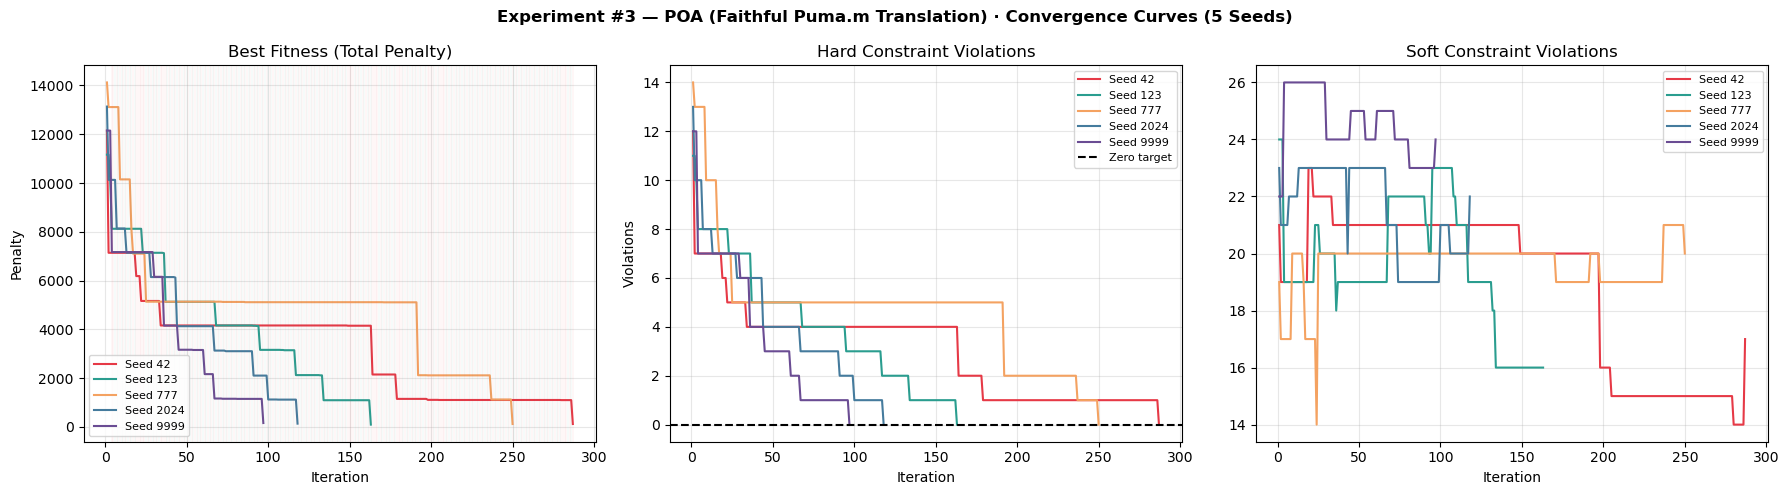


Convergence plot saved → poa_convergence_exp3_faithful.png


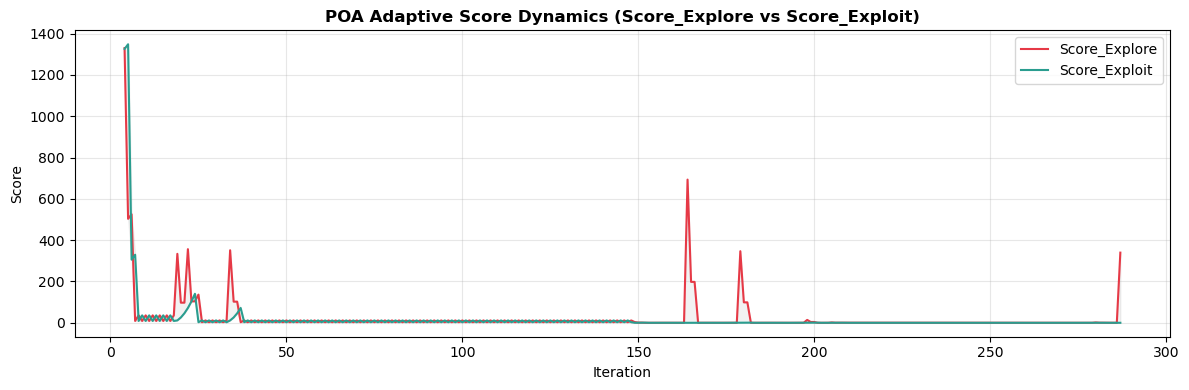

Score dynamics plot saved → poa_scores_dynamics.png

Best timetable → best_timetable_exp3.csv
  seed=123  hard=0  soft=16

RESULTS SUMMARY
 seed  best_fitness  hard_viol  soft_viol  n_iterations  runtime_s  solved
   42         120.0          0         17           287      37.05    True
  123          95.0          0         16           163      18.68    True
  777         120.0          0         20           250      30.25    True
 2024         135.0          0         22           118      15.41    True
 9999         160.0          0         24            97      11.64    True

Mean fitness : 126
Std  fitness : 24
Solved       : 5 / 5
Mean runtime : 22.61 s


In [15]:
# ─────────────────────────────────────────────────────────────
# Cell 13 ▸ Run the POA Algorithm
# ─────────────────────────────────────────────────────────────

# ── Configuration  (mirrors main.m: N=30, T=500) ─────────────
POA_CONFIG = dict(
    n_pop    = 30,
    max_iter = 300,
    verbose  = True,
)

print("=" * 60)
print("EXPERIMENT #3 — POA with Fully-Random Initialization")
print("Faithful translation of Puma.m / Exploration.m / Exploitation.m")
print("=" * 60)

# ── Single main run ───────────────────────────────────────────
print("\n>>> MAIN RUN  (seed = 42) ...")
result = run_poa(**POA_CONFIG, seed=42)

# ── Decode best schedule ──────────────────────────────────────
best_asgn = decode_solution(result["best_vec"])
df_best   = pd.DataFrame(best_asgn)

print("\n" + "=" * 60)
print("BEST SCHEDULE — SUMMARY")
print("=" * 60)
print(f"Hard violations : {result['best_hard']}")
print(f"Soft violations : {result['best_soft']}")
print(f"Total penalty   : {result['best_fitness']:,.0f}")
print(f"Runtime         : {result['elapsed_s']:.2f} s")
print(f"Iterations run  : {result['n_iterations']}")

print("\nConstraint breakdown:")
_, _, _, det = evaluate_fitness(result["best_vec"])
w_map = {"H1":W_H1,"H2":W_H2,"H3":W_H3,"H4":W_H4,"S1":W_S1,"S2":W_S2}
for k, v in det.items():
    w  = w_map[k[:2]]
    ok = "✓" if v == 0 else "✗"
    print(f"  {ok} {k:28s}: {v:5d}  (×{w:5d} = {v*w:8,.0f})")

print("\nBest schedule sample (first 15 units):")
print(df_best[["unit_id","teacher_id","room_id","day",
               "start_slot","end_slot","session_type"]].head(15).to_string(index=False))

# ── 5-seed robustness test ────────────────────────────────────
SEEDS   = [42, 123, 777, 2024, 9999]
results = [result]   # seed-42 result already computed

print("\n" + "=" * 60)
print("ROBUSTNESS — 5 seeds")
print("=" * 60)
print(f"{'Seed':>6}  {'Fitness':>10}  {'Hard':>6}  {'Soft':>6}  "
      f"{'Iters':>6}  {'Time(s)':>8}  {'Solved':>7}")
print("─" * 60)

_, bh42, bs42, _ = evaluate_fitness(result["best_vec"])
print(f"{42:>6}  {result['best_fitness']:>10,.0f}  {bh42:>6}  {bs42:>6}  "
      f"{result['n_iterations']:>6}  {result['elapsed_s']:>8.1f}  "
      f"{'YES' if bh42==0 else 'no':>7}")

for s in SEEDS[1:]:
    r = run_poa(**{**POA_CONFIG, "verbose": False}, seed=s)
    results.append(r)
    print(f"{s:>6}  {r['best_fitness']:>10,.0f}  {r['best_hard']:>6}  "
          f"{r['best_soft']:>6}  {r['n_iterations']:>6}  "
          f"{r['elapsed_s']:>8.1f}  {'YES' if r['best_hard']==0 else 'no':>7}")

# ── POA phase-selection analysis ─────────────────────────────
print("\n" + "=" * 60)
print("POA ADAPTIVE PHASE SELECTION ANALYSIS (main run)")
print("=" * 60)
hist = result["history"]
explore_iters  = sum(1 for h in hist if h.get("phase") == "EXPLORE")
exploit_iters  = sum(1 for h in hist if h.get("phase") == "EXPLOIT")
unexper_iters  = sum(1 for h in hist if h.get("phase") == "UNEXPERIENCED")
print(f"Unexperienced phase   : {unexper_iters} iterations")
print(f"Experienced — EXPLORE : {explore_iters} iterations")
print(f"Experienced — EXPLOIT : {exploit_iters} iterations")

# ── Convergence plot ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    "Experiment #3 — POA (Faithful Puma.m Translation) · Convergence Curves (5 Seeds)",
    fontsize=12, fontweight="bold"
)
colors = ["#e63946","#2a9d8f","#f4a261","#457b9d","#6a4c93"]

for r, color, s in zip(results, colors, SEEDS):
    iters = [h["iteration"] for h in r["history"]]
    fits  = [h["best_fitness"] for h in r["history"]]
    hard  = [h["best_hard"]    for h in r["history"]]
    soft  = [h["best_soft"]    for h in r["history"]]
    label = f"Seed {s}"
    axes[0].plot(iters, fits, color=color, lw=1.5, label=label)
    axes[1].plot(iters, hard, color=color, lw=1.5, label=label)
    axes[2].plot(iters, soft, color=color, lw=1.5, label=label)

axes[0].set_title("Best Fitness (Total Penalty)")
axes[1].set_title("Hard Constraint Violations")
axes[2].set_title("Soft Constraint Violations")
axes[1].axhline(0, color="black", lw=1.5, ls="--", label="Zero target")
for ax in axes:
    ax.set_xlabel("Iteration"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
axes[0].set_ylabel("Penalty")
axes[1].set_ylabel("Violations")

# Mark phase transitions on main-run fitness plot
if len(hist) > 3:
    for h in hist[3:]:
        clr = "#e63946" if h.get("phase")=="EXPLORE" else "#2a9d8f"
        axes[0].axvline(h["iteration"], color=clr, alpha=0.04)

plt.tight_layout()
plt.savefig("poa_convergence_exp3_faithful.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nConvergence plot saved → poa_convergence_exp3_faithful.png")

# ── Score dynamics plot (Experienced Phase only) ──────────────
exp_hist = [h for h in hist if h.get("phase") in ("EXPLORE","EXPLOIT")]
if exp_hist:
    fig2, ax2 = plt.subplots(figsize=(12, 4))
    iters_exp  = [h["iteration"]     for h in exp_hist]
    se_vals    = [h["Score_Explore"] for h in exp_hist]
    sx_vals    = [h["Score_Exploit"] for h in exp_hist]
    ax2.plot(iters_exp, se_vals, color="#e63946", lw=1.5, label="Score_Explore")
    ax2.plot(iters_exp, sx_vals, color="#2a9d8f", lw=1.5, label="Score_Exploit")
    ax2.fill_between(iters_exp,
                     [max(a,b) for a,b in zip(se_vals,sx_vals)],
                     [min(a,b) for a,b in zip(se_vals,sx_vals)],
                     alpha=0.1, color="gray")
    ax2.set_title("POA Adaptive Score Dynamics (Score_Explore vs Score_Exploit)", fontweight="bold")
    ax2.set_xlabel("Iteration"); ax2.set_ylabel("Score")
    ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("poa_scores_dynamics.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Score dynamics plot saved → poa_scores_dynamics.png")

# ── Export best timetable ────────────────────────────────────
best_r = min(results, key=lambda r: (r["best_hard"], r["best_fitness"]))
pd.DataFrame(decode_solution(best_r["best_vec"])).to_csv(
    "best_timetable_exp3.csv", index=False)
print(f"\nBest timetable → best_timetable_exp3.csv")
print(f"  seed={best_r['seed']}  hard={best_r['best_hard']}  soft={best_r['best_soft']}")

# ── Summary statistics ────────────────────────────────────────
df_res = pd.DataFrame([{
    "seed"        : r["seed"],
    "best_fitness": r["best_fitness"],
    "hard_viol"   : r["best_hard"],
    "soft_viol"   : r["best_soft"],
    "n_iterations": r["n_iterations"],
    "runtime_s"   : round(r["elapsed_s"], 2),
    "solved"      : r["best_hard"] == 0,
} for r in results])

print("\n" + "=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
print(df_res.to_string(index=False))
print(f"\nMean fitness : {df_res['best_fitness'].mean():,.0f}")
print(f"Std  fitness : {df_res['best_fitness'].std():,.0f}")
print(f"Solved       : {df_res['solved'].sum()} / {len(df_res)}")
print(f"Mean runtime : {df_res['runtime_s'].mean():.2f} s")
